In [ ]:
# MexCulture142_Altered/
# ├── images/
# │   ├── Colonial_AcademiaDeBellasArtes_Queretaro_N_1.png
# │   ├── Colonial_AcademiaDeBellasArtes_Queretaro_N_2.png
# │   └── Colonial_AdvocacionesDeLaIglesiaDeSanSimon_Michoacan_N_1.png
# │
# ├── gazefixationsdensitymaps/
# │   ├── Colonial_AcademiaDeBellasArtes_Queretaro_GFDM_N_1.png
# │   ├── Colonial_AcademiaDeBellasArtes_Queretaro_GFDM_N_2.png
# │   └── Colonial_AdvocacionesDeLaIglesiaDeSanSimon_Michoacan_GFDM_N_1.png
# │
# └── fixations/
#     ├── Colonial_AcademiaDeBellasArtes_Queretaro_GazeFix_N_1.txt [cite: 1]
#     ├── Colonial_AcademiaDeBellasArtes_Queretaro_GazeFix_N_2.txt [cite: 5]
#     └── Colonial_AdvocacionesDeLaIglesiaDeSanSimon_Michoacan_GazeFix_N_1.txt [cite: 2]

In [ ]:
##################################################################################
################################## IMPORTURI #####################################
##################################################################################

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.models import resnet34, ResNet34_Weights
from torchvision import transforms
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
import glob
import random
from PIL import Image, ImageEnhance, ImageOps
import torchvision.transforms.functional as F
from tqdm.notebook import tqdm
import argparse
import sys
from skimage.util import random_noise

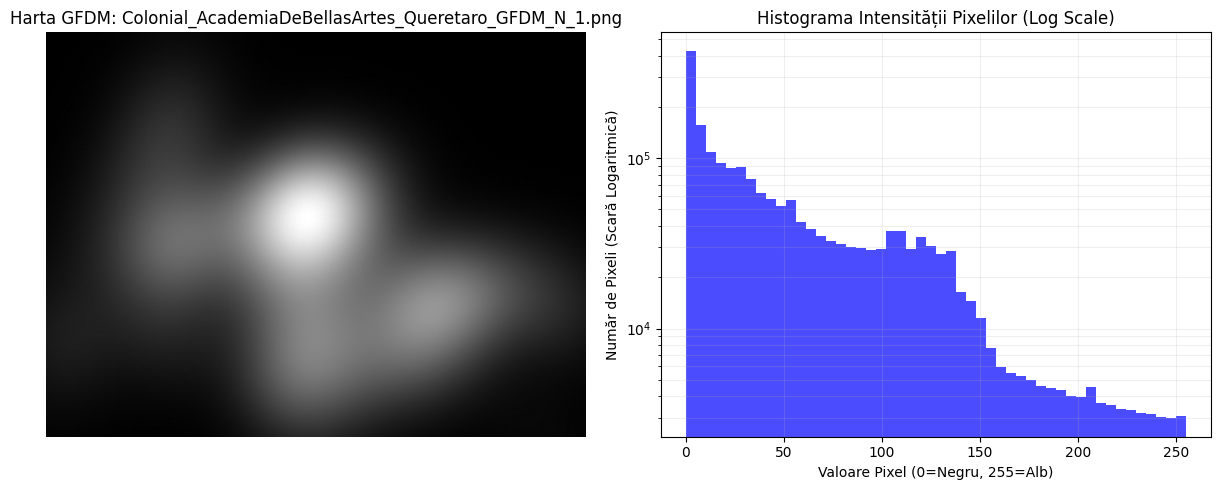

--------------------------------------------------
INTERPRETARE PENTRU PROFESOR:
Graficul din dreapta arată o distribuție continuă a valorilor.
Dacă era o problemă de CLASIFICARE (binară), am fi avut doar două bare: una la 0 și una la 255.
Faptul că avem valori intermediare (ex: 50, 120, 200) demonstrează că este o problemă de REGRESIE.
--------------------------------------------------


In [ ]:
##################################################################################
########################### REGRESIE VS CLASIFICARE ##############################
##################################################################################

ROOT_DATA_DIR = 'C:\\Users\\maria\\Documents\\GitHub\\Saliency-Prediction-on-Mexican-object-dataset-MexCulture142\\MexCulture142_Altered'

# Alegem o hartă de saliență aleatorie pentru analiză
# Asigură-te că ROOT_DATA_DIR este definit corect anterior
example_gfdm_dir = os.path.join(ROOT_DATA_DIR, 'gazefixationsdensitymaps')
sample_file = os.listdir(example_gfdm_dir)[0] # Luăm primul fișier
sample_path = os.path.join(example_gfdm_dir, sample_file)

# Încărcăm imaginea și o transformăm în array NumPy
gfdm_img = Image.open(sample_path).convert('L') # L = Grayscale (0-255)
pixel_values = np.array(gfdm_img).flatten() # O transformăm într-un șir lung de numere

# Plotăm Histograma
plt.figure(figsize=(12, 5))

# 1. Afișăm Harta
plt.subplot(1, 2, 1)
plt.imshow(gfdm_img, cmap='gray')
plt.title(f"Harta GFDM: {sample_file}")
plt.axis('off')

# 2. Afișăm Distribuția Valorilor
plt.subplot(1, 2, 2)
plt.hist(pixel_values, bins=50, color='blue', alpha=0.7, log=True)
plt.title("Histograma Intensității Pixelilor (Log Scale)")
plt.xlabel("Valoare Pixel (0=Negru, 255=Alb)")
plt.ylabel("Număr de Pixeli (Scară Logaritmică)")
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.show()

print("-" * 50)
print("Graficul din dreapta arată o distribuție continuă a valorilor.")
print("Dacă era o problemă de CLASIFICARE (binară), am fi avut doar două bare: una la 0 și una la 255.")
print("Faptul că avem valori intermediare (ex: 50, 120, 200) demonstrează că este o problemă de REGRESIE.")
print("-" * 50)

In [5]:
##################################################################################
############################## Functii augmentari ################################
##################################################################################

# --- 2. FUNCȚII AJUTĂTOARE PENTRU ZGOMOT (Photometric) ---

def add_gaussian_noise(img_pil, var=0.01):
    img = np.array(img_pil) / 255.0
    noisy = random_noise(img, mode='gaussian', var=var)
    return Image.fromarray((noisy * 255).astype(np.uint8))

def add_salt_pepper_noise(img_pil, amount=0.05):
    img = np.array(img_pil) / 255.0
    noisy = random_noise(img, mode='s&p', amount=amount)
    return Image.fromarray((noisy * 255).astype(np.uint8))

def add_speckle_noise(img_pil, var=0.01):
    img = np.array(img_pil) / 255.0
    noisy = random_noise(img, mode='speckle', var=var)
    return Image.fromarray((noisy * 255).astype(np.uint8))

# --- 3. LISTA DE TRANSFORMĂRI DETERMINISTE (36 în total) ---

# 1. Transformări Geometrice (15) - Aplicat la X ȘI Y
GEO_TRANSFORMS = {
    'geo_hflip': lambda img: F.hflip(img),
    'geo_vflip': lambda img: F.vflip(img),
    'geo_rot_90': lambda img: F.rotate(img, 90, fill=0),
    'geo_rot_180': lambda img: F.rotate(img, 180, fill=0),
    'geo_rot_270': lambda img: F.rotate(img, 270, fill=0),
    'geo_rot_15': lambda img: F.rotate(img, 15, fill=0),
    'geo_rot_neg_15': lambda img: F.rotate(img, -15, fill=0),
    'geo_shear_x_10': lambda img: img.transform(img.size, Image.AFFINE, (1, 0.1, 0, 0, 1, 0)),
    'geo_shear_y_10': lambda img: img.transform(img.size, Image.AFFINE, (1, 0, 0, 0.1, 1, 0)),
    'geo_shear_x_neg_10': lambda img: img.transform(img.size, Image.AFFINE, (1, -0.1, 0, 0, 1, 0)),
    'geo_shear_y_neg_10': lambda img: img.transform(img.size, Image.AFFINE, (1, 0, 0, -0.1, 1, 0)),
    'geo_translate_x_10': lambda img: img.transform(img.size, Image.AFFINE, (1, 0, 50, 0, 1, 0)),
    'geo_translate_y_10': lambda img: img.transform(img.size, Image.AFFINE, (1, 0, 0, 0, 1, 50)),
    'geo_crop_zoom_80': lambda img: F.center_crop(img, [int(s * 0.8) for s in img.size]),
    'geo_crop_zoom_90': lambda img: F.center_crop(img, [int(s * 0.9) for s in img.size]),
}

# 2. Transformări de Culoare (15) - Aplicat DOAR la X
COLOR_TRANSFORMS = {
    'color_brightness_high': lambda img: ImageEnhance.Brightness(img).enhance(1.5),
    'color_brightness_low': lambda img: ImageEnhance.Brightness(img).enhance(0.5),
    'color_contrast_high': lambda img: ImageEnhance.Contrast(img).enhance(1.5),
    'color_contrast_low': lambda img: ImageEnhance.Contrast(img).enhance(0.5),
    'color_saturation_high': lambda img: ImageEnhance.Color(img).enhance(1.5),
    'color_saturation_low': lambda img: ImageEnhance.Color(img).enhance(0.5),
    'color_sharpness_high': lambda img: ImageEnhance.Sharpness(img).enhance(2.0),
    'color_sharpness_low': lambda img: ImageEnhance.Sharpness(img).enhance(0.5),
    'color_hue_p0_1': lambda img: F.adjust_hue(img, 0.1),
    'color_hue_n0_1': lambda img: F.adjust_hue(img, -0.1),
    'color_grayscale': lambda img: ImageOps.grayscale(img).convert('RGB'),
    'color_solarize': lambda img: ImageOps.solarize(img, threshold=128),
    'color_posterize': lambda img: ImageOps.posterize(img, bits=4),
    'color_autocontrast': lambda img: ImageOps.autocontrast(img),
    'color_equalize': lambda img: ImageOps.equalize(img),
}

# 3. Transformări de Zgomot (6) - Aplicat DOAR la X
NOISE_TRANSFORMS = {
    'noise_gauss_0_01': lambda img: add_gaussian_noise(img, var=0.01),
    'noise_gauss_0_02': lambda img: add_gaussian_noise(img, var=0.02),
    'noise_gauss_0_05': lambda img: add_gaussian_noise(img, var=0.05),
    'noise_sp_0_01': lambda img: add_salt_pepper_noise(img, amount=0.01),
    'noise_sp_0_05': lambda img: add_salt_pepper_noise(img, amount=0.05),
    'noise_speckle_0_01': lambda img: add_speckle_noise(img, var=0.01),
}


# --- 4. FUNCȚIA PRINCIPALĂ DE RULARE (Notebook) ---

def run_augmentation_notebook(source_dir, output_dir, total_generated=0):
    
    # 1. Crearea căilor și a directoarelor
    img_dir = os.path.join(source_dir, 'images')
    gfdm_dir = os.path.join(source_dir, 'gazefixationsdensitymaps')
    
    out_img_dir = os.path.join(output_dir, 'images')
    out_gfdm_dir = os.path.join(output_dir, 'gazefixationsdensitymaps')

    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_gfdm_dir, exist_ok=True)

    # 2. Găsirea imaginilor
    image_paths = sorted(glob.glob(os.path.join(img_dir, '*.png')))
    if not image_paths:
        print(f"EROARE: Nu am găsit imagini .png în {img_dir}. Verifică calea '{source_dir}'.")
        return

    print(f"Am găsit {len(image_paths)} imagini originale. Se vor genera {len(GEO_TRANSFORMS) + len(COLOR_TRANSFORMS) + len(NOISE_TRANSFORMS)} augmentări pe imagine.")
    
    total_generated = 0
    
    # 3. Procesarea lotului (cu bară de progres)
    for img_path in tqdm(image_paths, desc="Procesare imagini"):
        
        base_name = os.path.basename(img_path).replace('.png', '')
        gfdm_name = base_name.replace('_N_', '_GFDM_N_') + '.png'
        gfdm_path = os.path.join(gfdm_dir, gfdm_name)
        
        if not os.path.exists(gfdm_path):
            tqdm.write(f"ATENȚIE: Harta {gfdm_name} lipsește. Se sare peste {base_name}")
            continue

        try:
            img_x_orig = Image.open(img_path).convert('RGB')
            img_y_orig = Image.open(gfdm_path).convert('L')
        except Exception as e:
            tqdm.write(f"EROARE la încărcarea {base_name}: {e}. Se sare peste.")
            continue
            
        # 4. Salvarea Originalului (aug_000)
        img_x_orig.save(os.path.join(out_img_dir, f"{base_name}_aug_000_original.png"))
        img_y_orig.save(os.path.join(out_gfdm_dir, f"{gfdm_name.replace('.png', '')}_aug_000_original.png"))
        total_generated += 1
        
        # 5. Aplicarea Transformărilor
        all_transforms = [(GEO_TRANSFORMS, 'geo', True), 
                          (COLOR_TRANSFORMS, 'color', False), 
                          (NOISE_TRANSFORMS, 'noise', False)]

        for transform_set, prefix, is_geometric in all_transforms:
            for aug_name, transform_func in transform_set.items():
                
                try:
                    aug_x = transform_func(img_x_orig)

                    if is_geometric:
                        # Aplică aceeași transformare la Y
                        aug_y = transform_func(img_y_orig)
                        # Redimensionează înapoi dacă crop/shear a schimbat mărimea
                        if aug_x.size != img_x_orig.size:
                            aug_x = aug_x.resize(img_x_orig.size, Image.BILINEAR)
                            aug_y = aug_y.resize(img_y_orig.size, Image.NEAREST)
                    else:
                        # Păstrează harta originală (Y) pentru aug. fotometrice
                        aug_y = img_y_orig
                        
                    # 6. Salvarea (daca exista deja augmentari, treci peste si afiseaza un mesaj)
                    if os.path.exists(os.path.join(out_img_dir, f"{base_name}_{aug_name}.png")):
                        tqdm.write(f"ATENȚIE: Augmentarea {aug_name} pentru {base_name} există deja. Se sare peste.")
                        continue
                    else:
                        new_img_name = f"{base_name}_{aug_name}.png"
                        new_gfdm_name = f"{gfdm_name.replace('.png', '')}_{aug_name}.png"
                    
                        aug_x.save(os.path.join(out_img_dir, new_img_name))
                        aug_y.save(os.path.join(out_gfdm_dir, new_gfdm_name))
                        total_generated += 1
                    
                except Exception as e:
                    tqdm.write(f"EROARE la {aug_name} pe {base_name}: {e}")


In [6]:
##################################################################################
############################# Aplicare augmentari ################################
##################################################################################

# --- 1. CONFIGURAȚIA FOLDERELOR ---
# Asigură-te că folderul 'MexCulture142' se află la același nivel cu notebook-ul tău.
SOURCE_DIR = "MexCulture142_Altered"
OUTPUT_DIR = "MexCulture142_Augmented"
# -----------------------------------

# --- EXECUTAREA SCRIPTULUI ---
# Rulați acest bloc în Jupyter Notebook:
total_generated = 0
run_augmentation_notebook(SOURCE_DIR, OUTPUT_DIR, total_generated)

print("\n-------------------------------------------------")
print("Generare finalizată.")
print(f"Total imagini generate: {total_generated}")
print(f"Imaginile au fost salvate în: {OUTPUT_DIR}")
print("-------------------------------------------------")

Am găsit 284 imagini originale. Se vor genera 36 augmentări pe imagine.


Procesare imagini:   0%|          | 0/284 [00:00<?, ?it/s]

ATENȚIE: Augmentarea geo_hflip pentru Colonial_AcademiaDeBellasArtes_Queretaro_N_1 există deja. Se sare peste.
ATENȚIE: Augmentarea geo_vflip pentru Colonial_AcademiaDeBellasArtes_Queretaro_N_1 există deja. Se sare peste.
ATENȚIE: Augmentarea geo_rot_90 pentru Colonial_AcademiaDeBellasArtes_Queretaro_N_1 există deja. Se sare peste.
ATENȚIE: Augmentarea geo_rot_180 pentru Colonial_AcademiaDeBellasArtes_Queretaro_N_1 există deja. Se sare peste.
ATENȚIE: Augmentarea geo_rot_270 pentru Colonial_AcademiaDeBellasArtes_Queretaro_N_1 există deja. Se sare peste.
ATENȚIE: Augmentarea geo_rot_15 pentru Colonial_AcademiaDeBellasArtes_Queretaro_N_1 există deja. Se sare peste.
ATENȚIE: Augmentarea geo_rot_neg_15 pentru Colonial_AcademiaDeBellasArtes_Queretaro_N_1 există deja. Se sare peste.
ATENȚIE: Augmentarea geo_shear_x_10 pentru Colonial_AcademiaDeBellasArtes_Queretaro_N_1 există deja. Se sare peste.
ATENȚIE: Augmentarea geo_shear_y_10 pentru Colonial_AcademiaDeBellasArtes_Queretaro_N_1 există d

In [2]:
##################################################################################
################################ Model + Dataset #################################
##################################################################################

# --- 1. Definirea Arhitecturii Modelului (ResNet34 + Saliency Head) ---
# (Această clasă rămâne neschimbată)

class SaliencyModel(nn.Module):
    """
    Arhitectura modelului: ResNet34 (Backbone) + Saliency Head (Decodor).
    """
    def __init__(self):
        super(SaliencyModel, self).__init__()
        
        # Încarcă ResNet34 pre-antrenat
        base_model = resnet34(weights=ResNet34_Weights.IMAGENET1K_V1)
        
        # Extractorul de caracteristici (fără ultimele 2 straturi)
        self.feature_extractor = nn.Sequential(*list(base_model.children())[:-2])
        
        # Capul de Saliență (Saliency Head)
        # Transformă (512, 7, 7) -> (1, 32, 32)
        self.saliency_head = nn.Sequential(
            nn.Conv2d(512, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(size=(32, 32), mode='bilinear', align_corners=False),
            nn.Conv2d(64, 1, kernel_size=1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        features = self.feature_extractor(x)
        saliency_map = self.saliency_head(features)
        return saliency_map

# --- 2. Definirea Setului de Date (Versiunea SIMPLĂ, FĂRĂ AUGMENTARE) ---

class MexCultureDataset(Dataset):
    """
    Clasa Dataset personalizată, simplă.
    Încarcă o imagine (Input) și harta sa GFDM (Target)
    și aplică transformările de bază (Resize, ToTensor).
    """
    def __init__(self, root_dir, transform_input=None, target_size=(32, 32)):
        self.image_dir = os.path.join(root_dir, 'images')
        self.gfdm_dir = os.path.join(root_dir, 'gazefixationsdensitymaps')
        
        self.image_files = [f for f in os.listdir(self.image_dir) if f.endswith('.png')]
        
        # Primește transformările pentru Input (X) ca parametru
        self.transform_input = transform_input
        self.target_size = target_size
        
        # Transformare standard pentru harta țintă (GFDM - Y)
        self.transform_target = transforms.Compose([
            transforms.Resize(self.target_size, 
                              interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor() 
        ])

    def __len__(self):
        # Returnează numărul total de eșantioane (imagini)
        return len(self.image_files)

    def __getitem__(self, idx):
        # --- A. Încărcare Fișiere ---
        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_name)
        
        gfdm_name = img_name.replace('.png', '').replace('_N_', '_GFDM_N_') + '.png'
        gfdm_path = os.path.join(self.gfdm_dir, gfdm_name)
        
        # Deschide imaginea (X) și harta (Y)
        input_image = Image.open(img_path).convert('RGB')
        target_gfdm_image = Image.open(gfdm_path).convert('L')
        
        # --- B. Aplicare Transformări (Fără Augmentare) ---
        
        # Aplică transformările de intrare (Resize, ToTensor, Normalize)
        if self.transform_input:
            input_tensor = self.transform_input(input_image)
        
        # Aplică transformările țintă (Resize 32x32, ToTensor)
        target_tensor = self.transform_target(target_gfdm_image)
        
        return input_tensor, target_tensor



In [ ]:
##################################################################################
############################ Antrenare altered ###################################
##################################################################################

if __name__ == "__main__":
    
    # Parametrii
    ROOT_DATA_DIR = 'MexCulture142_Altered' # Asumând că folderele sunt în directorul curent
    SPLIT_RATIO = 0.8   # 80% Antrenare, 20% Testare/validare
    BATCH_SIZE = 16      
    NUM_EPOCHS = 10     
    LEARNING_RATES = [0.001, 0.0001, 0.00005, 0.00001] # Testăm: 0.001, 0.0001, 0.00001

    # Dicționar pentru a stoca rezultatele
    altered_results = {}
    
    # Detectează GPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Se utilizează dispozitivul: {device}")

    # --- Definirea Transformărilor de Bază (CU Augmentare) ---
    # Acestea sunt necesare pentru a pregăti imaginea pentru ResNet
    input_transform = transforms.Compose([
        transforms.Resize((224, 224)), # Redimensionează imaginea la 224x224
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    # Inițializare Dataset
    print(f"Încărcare set de date din: {ROOT_DATA_DIR}")
    try:
        full_dataset = MexCultureDataset(root_dir=ROOT_DATA_DIR, transform_input=input_transform)
        total_size = len(full_dataset)
        print(f"Total imagini găsite: {total_size}")
        
        if total_size == 0:
            raise FileNotFoundError("Datasetul este gol. Verifică folderul 'MexCulture142_Augmented'.")
        
        # 2. ÎMPĂRȚIREA 80% / 20%
        train_size = int(SPLIT_RATIO * total_size)
        test_size = total_size - train_size
        
        # random_split amestecă indicii și împarte dataset-ul
        train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])
        
        print(f"Dataset împărțit: {train_size} Antrenare | {test_size} Testare")

        # 3. DataLoaders
        # num_workers=0 pentru Windows (pentru a evita erorile de multiprocessing)
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
        test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

        for lr in LEARNING_RATES:
            print(f"\n--- Testare Learning Rate: {lr} ---")
            
            # 4. Model, Loss, Optimizer
            model = SaliencyModel().to(device)
            criterion = nn.MSELoss() 
            optimizer = optim.Adam(model.parameters(), lr=lr)

            # Listele pentru grafice
            altered_train_losses = []
            altered_test_losses = []

            # Șterge fișierul saliency_resnet34.pth daca exista deja
            if os.path.exists(f'results\\altered\\saliency_resnet34_lr_{lr}.pth'):
                print("Șterge fișierul existent...")
                os.remove(f'results\\altered\\saliency_resnet34_lr_{lr}.pth')
            else:
                print("Nu există un fișier existent de șters.")

            print("--- Începere Antrenare (FARA Augmentare) ---")

            # Bucla de Antrenare
            for epoch in range(NUM_EPOCHS):

                # --- FAZA DE ANTRENARE ---
                model.train() 
                running_train_loss = 0.0
                
                for inputs, targets in train_loader:  # Folosim tqdm pentru progres
                    inputs, targets = inputs.to(device), targets.to(device)
                    
                    optimizer.zero_grad()
                    predictions = model(inputs)
                    loss = criterion(predictions, targets)
                    loss.backward()
                    optimizer.step()
                    
                    running_train_loss += loss.item()
                
                avg_train_loss = running_train_loss / len(train_loader)
                altered_train_losses.append(avg_train_loss)
                
                # --- FAZA DE TESTARE (EVALUARE) ---
                model.eval()
                running_test_loss = 0.0
                
                with torch.no_grad(): # Nu calculăm gradienți la testare
                    for inputs, targets in test_loader: # Fără tqdm aici, să nu aglomerăm consola
                        inputs, targets = inputs.to(device), targets.to(device)
                        predictions = model(inputs)
                        loss = criterion(predictions, targets)
                        running_test_loss += loss.item()
                
                avg_test_loss = running_test_loss / len(test_loader)
                altered_test_losses.append(avg_test_loss)
                
                # Afișare rezultate epocă
                print(f"Epoca {epoch+1}/{NUM_EPOCHS} | Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f}")
                print("--------------------------- Train acc: {:.6f}% | Test acc: {:.6f}% ---------------------------".format((1 - avg_train_loss) * 100, (1 - avg_test_loss) * 100))

            # Salvăm istoricul pentru acest LR
            altered_results[lr] = {
                'train': altered_train_losses,
                'test': altered_test_losses
            }

            print("--- Antrenare Finalizată pentru LR: {lr} ---")
            
            # Salvarea modelului antrenat
            torch.save(model.state_dict(), f'results\\altered\\saliency_resnet34_lr_{lr}.pth')
            print(f"Modelul antrenat a fost salvat ca 'results\\altered\\saliency_resnet34_lr_{lr}.pth'")

    except FileNotFoundError as e:
        print(f"\nEROARE: Nu am putut găsi folderele de date.")
        print(f"Asigură-te că scriptul rulează în folderul care conține 'images/' și 'gazefixationsdensitymaps/'.")
        print(f"Detalii: {e}")

In [ ]:
##################################################################################
############################### Antrenare augmented ##############################
##################################################################################

# Training process

if __name__ == "__main__":
    
    # Parametrii
    ROOT_DATA_DIR = 'MexCulture142_Augmented' # Asumând că folderele sunt în directorul curent
    BATCH_SIZE = 16      
    NUM_EPOCHS = 10     
    LEARNING_RATES = [0.001, 0.0001, 0.00005, 0.00001] # Testăm: 0.001, 0.0001, 0.00001

    # Dicționar pentru a stoca rezultatele
    augmented_results = {}
    
    # Detectează GPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Se utilizează dispozitivul: {device}")

    # --- Definirea Transformărilor de Bază (CU Augmentare) ---
    # Acestea sunt necesare pentru a pregăti imaginea pentru ResNet
    input_transform = transforms.Compose([
        transforms.Resize((224, 224)), # Redimensionează imaginea la 224x224
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    # Inițializare Dataset
    print(f"Încărcare set de date din: {ROOT_DATA_DIR}")
    try:
        full_dataset = MexCultureDataset(root_dir=ROOT_DATA_DIR, transform_input=input_transform)
        total_size = len(full_dataset)
        print(f"Total imagini găsite: {total_size}")
        
        if total_size == 0:
            raise FileNotFoundError("Datasetul este gol. Verifică folderul 'MexCulture142_Altered'.")
        
        # 2. ÎMPĂRȚIREA 80% / 20%
        train_size = int(0.8 * total_size)
        test_size = total_size - train_size
        
        # random_split amestecă indicii și împarte dataset-ul
        train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])
        
        print(f"Dataset împărțit: {train_size} Antrenare | {test_size} Testare")

        # 3. DataLoaders
        # num_workers=0 pentru Windows (pentru a evita erorile de multiprocessing)
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
        test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

        for lr in LEARNING_RATES:
            print(f"\n--- Testare Learning Rate: {lr} ---")
            
            # 4. Model, Loss, Optimizer
            model = SaliencyModel().to(device)
            criterion = nn.MSELoss() 
            optimizer = optim.Adam(model.parameters(), lr=lr)

            # Listele pentru grafice
            augmented_train_losses = []
            augmented_test_losses = []

            print("--- Începere Antrenare (CU Augmentare) ---")

            # Bucla de Antrenare
            for epoch in range(NUM_EPOCHS):

                # --- FAZA DE ANTRENARE ---
                model.train() 
                running_train_loss = 0.0
                
                for inputs, targets in train_loader:  # Folosim tqdm pentru progres
                    inputs, targets = inputs.to(device), targets.to(device)
                    
                    optimizer.zero_grad()
                    predictions = model(inputs)
                    loss = criterion(predictions, targets)
                    loss.backward()
                    optimizer.step()
                    
                    running_train_loss += loss.item()
                
                avg_train_loss = running_train_loss / len(train_loader)
                augmented_train_losses.append(avg_train_loss)
                
                # --- FAZA DE TESTARE (EVALUARE) ---
                model.eval()
                running_test_loss = 0.0
                
                with torch.no_grad(): # Nu calculăm gradienți la testare
                    for inputs, targets in test_loader: # Fără tqdm aici, să nu aglomerăm consola
                        inputs, targets = inputs.to(device), targets.to(device)
                        predictions = model(inputs)
                        loss = criterion(predictions, targets)
                        running_test_loss += loss.item()
                
                avg_test_loss = running_test_loss / len(test_loader)
                augmented_test_losses.append(avg_test_loss)
                
                # Afișare rezultate epocă
                print(f"Epoca {epoch+1}/{NUM_EPOCHS} | Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f}")
                print("--------------------------- Train acc: {:.6f}% | Test acc: {:.6f}% ---------------------------".format((1 - avg_train_loss) * 100, (1 - avg_test_loss) * 100))

            # Salvăm istoricul pentru acest LR
            augmented_results[lr] = {
                'train': augmented_train_losses,
                'test': augmented_test_losses
            }

            print("--- Antrenare Finalizată pentru LR: {lr} ---")

            # Creeaza fișierul saliency_resnet34__*.pth daca nu exista deja
            if os.path.exists(f'results\\augmented\\saliency_resnet34_lr_{lr}.pth'):
                print("Fisierul exista deja...")
            else:
                torch.save(model.state_dict(), f'results\\augmented\\saliency_resnet34_lr_{lr}.pth')
                print(f"Modelul antrenat a fost salvat ca 'results\\augmented\\saliency_resnet34_lr_{lr}.pth'")

    except FileNotFoundError as e:
        print(f"\nEROARE: Nu am putut găsi folderele de date.")
        print(f"Asigură-te că scriptul rulează în folderul care conține 'images/' și 'gazefixationsdensitymaps/'.")
        print(f"Detalii: {e}")

Se utilizează dispozitivul: cuda
Încărcare set de date din: MexCulture142_Augmented
Total imagini găsite: 10508
Dataset împărțit: 8406 Antrenare | 2102 Testare

--- Testare Learning Rate: 0.001 ---
--- Începere Antrenare (CU Augmentare) ---
Epoca 1/10 | Train Loss: 0.091971 | Test Loss: 0.090326
--------------------------- Train acc: 90.802867% | Test acc: 90.967363% ---------------------------
Epoca 2/10 | Train Loss: 0.091824 | Test Loss: 0.090326
--------------------------- Train acc: 90.817628% | Test acc: 90.967363% ---------------------------
Epoca 3/10 | Train Loss: 0.091819 | Test Loss: 0.090326
--------------------------- Train acc: 90.818135% | Test acc: 90.967363% ---------------------------
Epoca 4/10 | Train Loss: 0.091845 | Test Loss: 0.090326
--------------------------- Train acc: 90.815467% | Test acc: 90.967363% ---------------------------
Epoca 5/10 | Train Loss: 0.091842 | Test Loss: 0.090326
--------------------------- Train acc: 90.815835% | Test acc: 90.967363% --

In [ ]:
# De modificat

##################################################################################
###################### Grafice Loss + Accuracy + CC score ########################
##################################################################################

# --- CELULA NOUĂ: Evaluare Avansată cu Metrica CC ---

def compute_cc(pred, target):
    """
    Calculează Coeficientul de Corelație Pearson (CC) între două hărți.
    CC = 1 -> Corelație perfectă (Predicția e identică cu Target-ul)
    CC = 0 -> Nicio corelație
    CC = -1 -> Corelație inversă
    """
    # Aplatizăm tensorii
    pred_flat = pred.view(-1)
    target_flat = target.view(-1)
    
    # Calculăm corelația
    vx = pred_flat - torch.mean(pred_flat)
    vy = target_flat - torch.mean(target_flat)
    
    cost = torch.sum(vx * vy) / (torch.sqrt(torch.sum(vx ** 2)) * torch.sqrt(torch.sum(vy ** 2)) + 1e-8)
    return cost.item()

def plot_experiment_results(results_dict, fallback_cc_scores=None):
    """
    Primește dicționarul 'results' și generează grafice pentru fiecare LR.
    Funcția e robustă la chei diferite: 'train' sau 'train_losses', 'test' sau 'test_losses',
    și folosește cc_scores din dictionar sau fallback_cc_scores dacă nu există.
    """
    for lr, data in results_dict.items():
        # suport pentru ambele convenții de chei
        train_losses = data.get('train', data.get('train_losses', []))
        test_losses = data.get('test', data.get('test_losses', []))
        cc_scores_lr = data.get('cc_scores', fallback_cc_scores if fallback_cc_scores is not None else [])

        # calcul medie CC dacă există scoruri
        avg_cc = np.mean(cc_scores_lr) if len(cc_scores_lr) > 0 else float('nan')

        print(f"\n" + "="*60)
        print(f"REZULTATE PENTRU LEARNING RATE: {lr}")
        print(f"Average CC: {avg_cc:.4f}" if not np.isnan(avg_cc) else "Average CC: N/A")
        print("="*60)

        # Creăm o figură mare cu 3 sub-grafice
        plt.figure(figsize=(18, 5))

        # Grafic 1: Distribuția CC (sau mesaj dacă nu există)
        plt.subplot(1, 3, 1)
        if len(cc_scores_lr) > 0:
            plt.hist(cc_scores_lr, bins=30, color='green', alpha=0.7, edgecolor='black')
            plt.title(f"Histograma Scorurilor CC (Avg: {avg_cc:.2f})")
            plt.xlabel("CC Score")
            plt.ylabel("Nr. Imagini")
        else:
            plt.text(0.5, 0.5, "No CC scores available", ha='center', va='center', fontsize=12)
            plt.title("CC Scores")
            plt.xticks([])
            plt.yticks([])

        # Grafic 2: Loss Curves (dacă există)
        plt.subplot(1, 3, 2)
        if len(train_losses) > 0 or len(test_losses) > 0:
            plt.plot(train_losses, label='Train Loss', marker='o' if len(train_losses)>0 else None)
            plt.plot(test_losses, label='Test Loss', marker='o' if len(test_losses)>0 else None)
            plt.title(f"Curba de Pierdere (Loss)")
            plt.xlabel("Epoci")
            plt.ylabel("MSE Loss")
            plt.legend()
            plt.grid(True, alpha=0.3)
        else:
            plt.text(0.5, 0.5, "No loss history available", ha='center', va='center')
            plt.title("Loss Curves")
            plt.xticks([])
            plt.yticks([])

        # Grafic 3: Accuracy (Estimată) (dacă există)
        plt.subplot(1, 3, 3)
        if len(train_losses) > 0 or len(test_losses) > 0:
            train_acc = [(1 - x)*100 for x in train_losses]
            test_acc = [(1 - x)*100 for x in test_losses]
            plt.plot(train_acc, label='Train Acc', color='orange')
            plt.plot(test_acc, label='Test Acc', color='red')
            plt.title(f"Acuratețe Estimată (%)")
            plt.xlabel("Epoci")
            plt.ylabel("Acc (%)")
            plt.legend()
            plt.grid(True, alpha=0.3)
        else:
            plt.text(0.5, 0.5, "No accuracy data", ha='center', va='center')
            plt.title("Accuracy (estimated)")
            plt.xticks([])
            plt.yticks([])

        plt.tight_layout()
        plt.show()

# Rulăm evaluarea pe setul de TEST
print("Se calculează scorul CC pe setul de testare...")
model.eval()
cc_scores = []

with torch.no_grad():
    for inputs, targets in test_loader: # Folosim test_loader definit anterior
        inputs, targets = inputs.to(device), targets.to(device)
        predictions = model(inputs)
        
        # Calculăm CC pentru fiecare imagine din batch
        for i in range(inputs.size(0)):
            score = compute_cc(predictions[i], targets[i])
            cc_scores.append(score)

avg_cc = np.mean(cc_scores) if len(cc_scores) > 0 else float('nan')
print(f"\nREZULTAT FINAL:")
print(f"Average Correlation Coefficient (CC): {avg_cc:.4f}" if not np.isnan(avg_cc) else "Average CC: N/A")
print("Interpretare: Cu cât este mai aproape de 1.0, cu atât modelul 'ghicește' mai bine unde se uită oamenii.")
print(f"\n{cc_scores}")

# --- APELARE ---
# Transmitem cc_scores ca fallback pentru cazurile în care dictionarul results nu conține 'cc_scores'
plot_experiment_results(results, fallback_cc_scores=cc_scores)

Procesare imagine: Example_images\alin.jpg
Se rulează predicțiile pentru 4 modele...


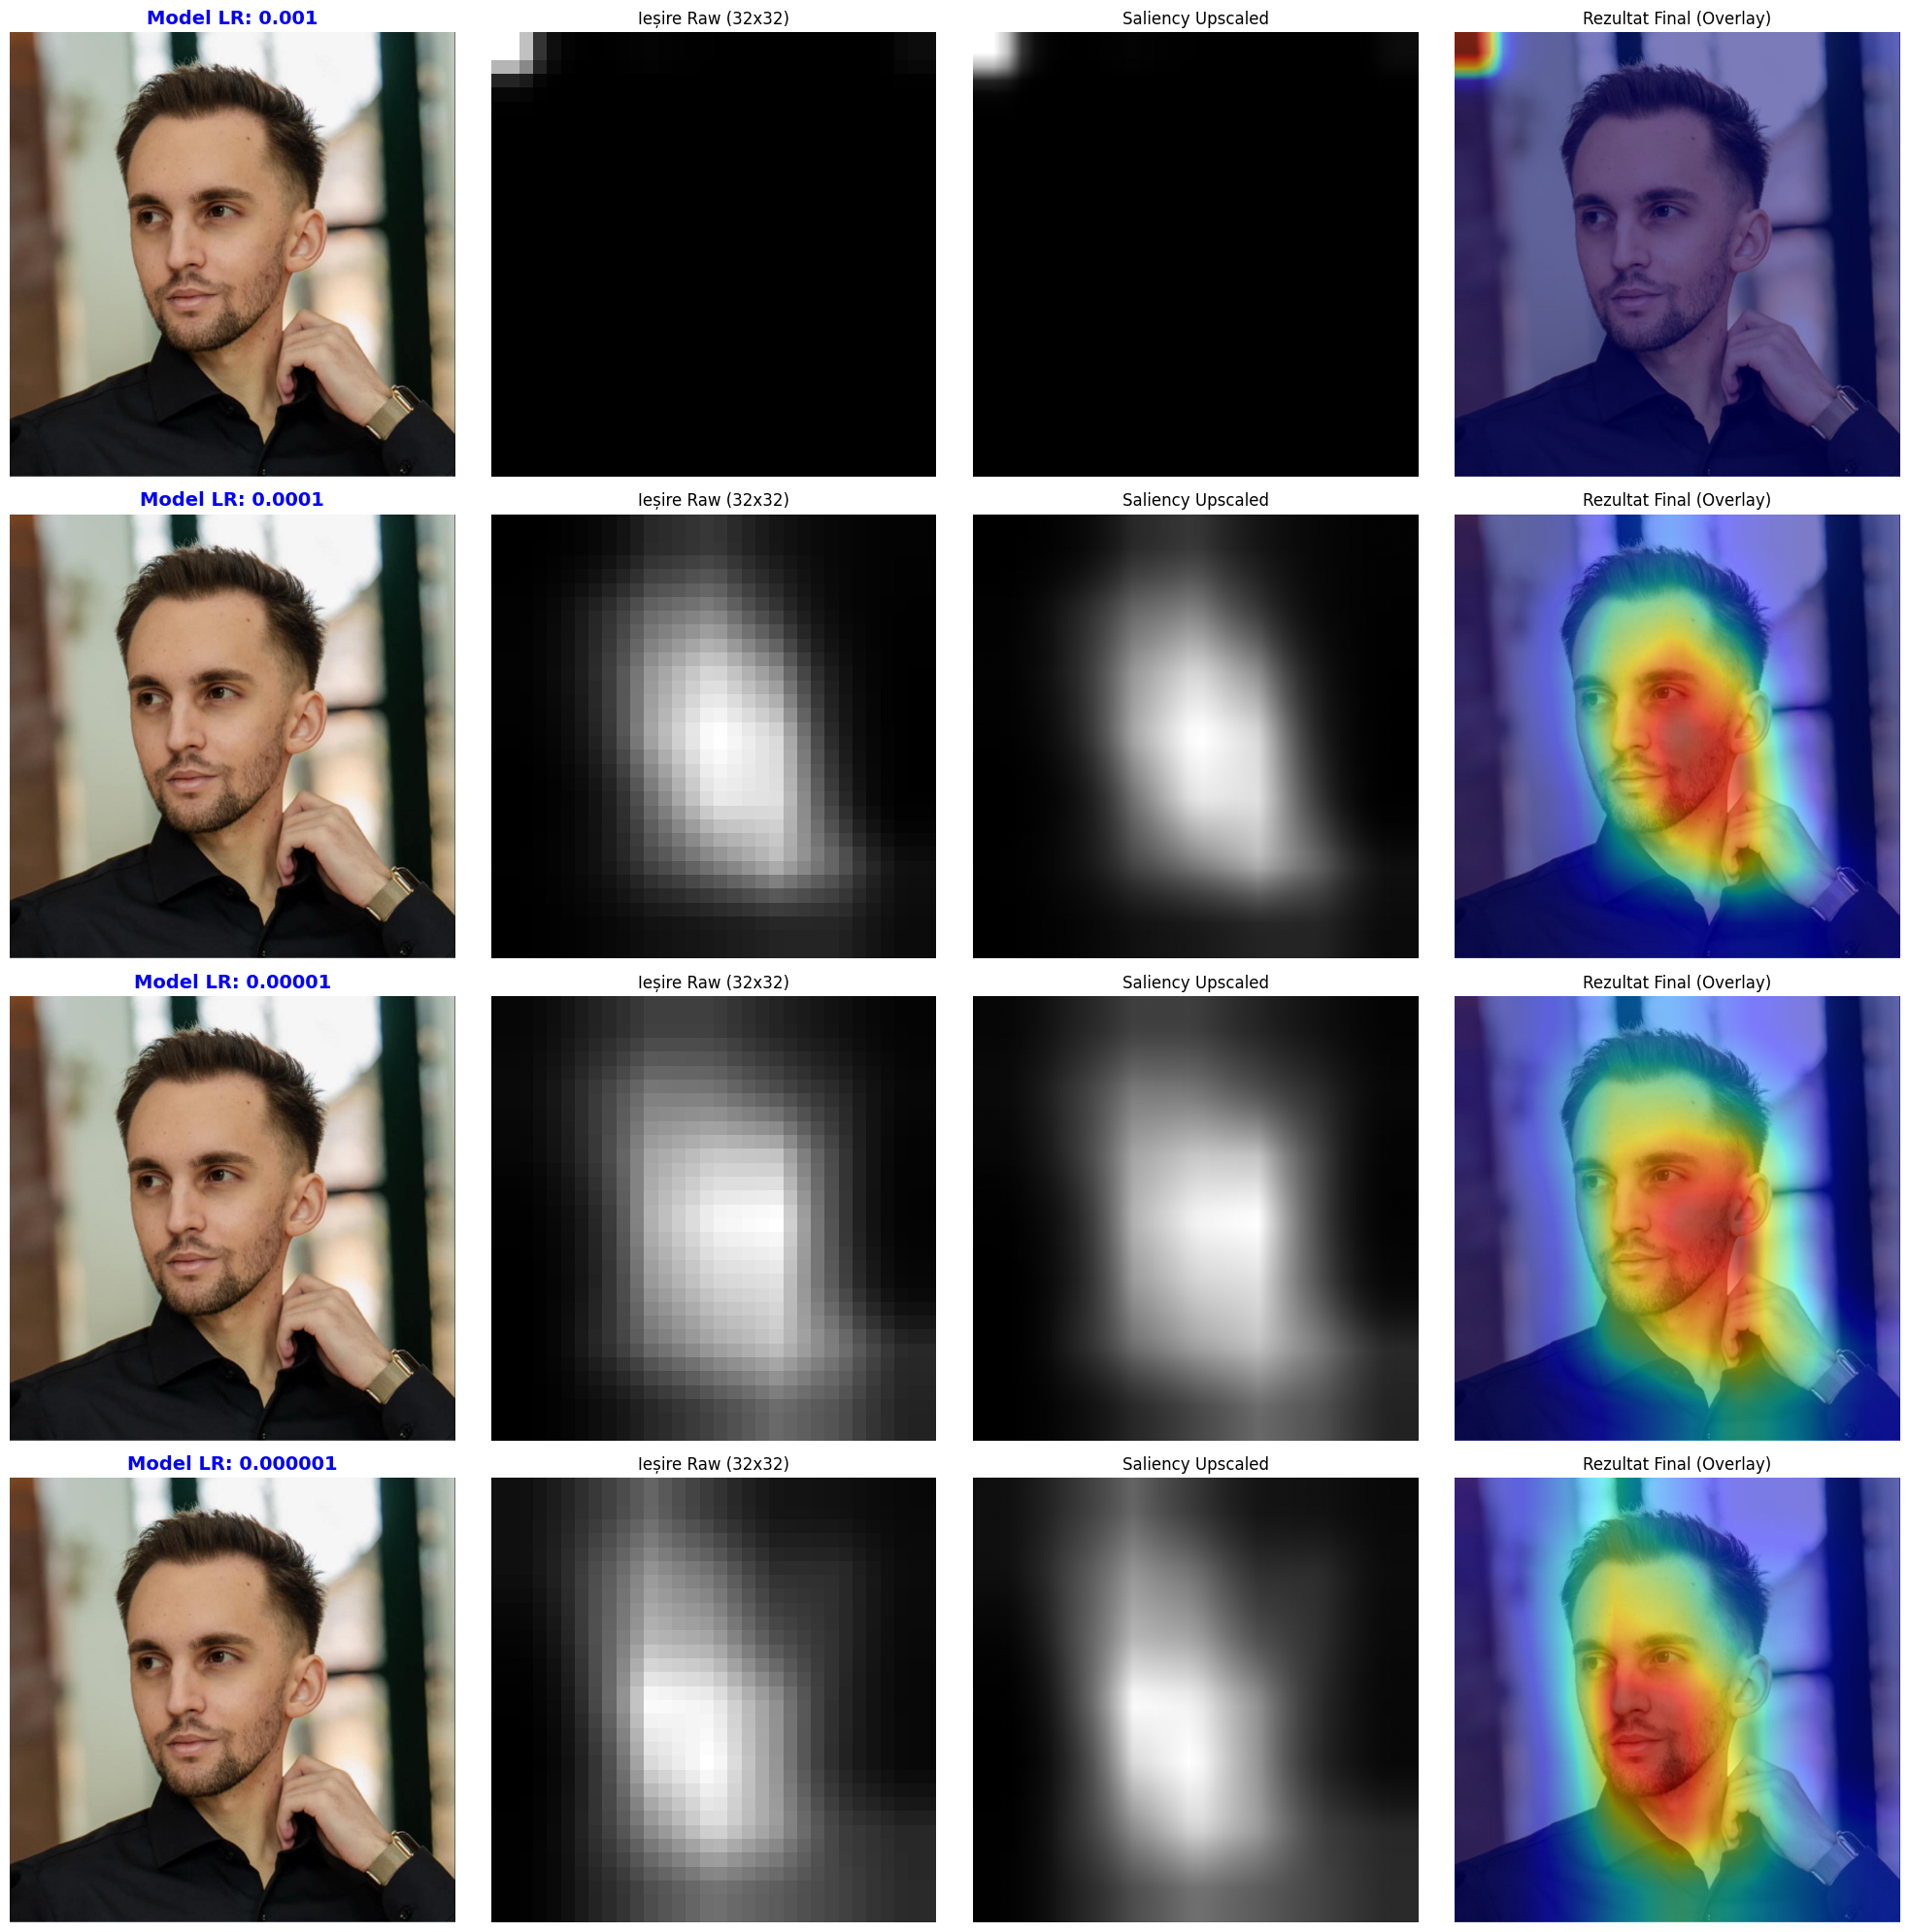

Vizualizare completă.


In [ ]:

def compare_models_by_lr(image_path, model_paths_dict, device):
    """
    Compară vizual rezultatele mai multor modele pe aceeași imagine.
    
    Argumente:
    - image_path: Calea către imaginea de test.
    - model_paths_dict: Un dicționar de forma {'Learning Rate': 'cale/catre/model.pth'}.
                        Ex: {'0.001': 'models/model_lr_0.001.pth', ...}
    - device: Dispozitivul (cuda/cpu).
    """

    if not os.path.exists(image_path):
        print(f"EROARE: Imaginea {image_path} nu există.")
        return

    # --- A. Pregătirea Imaginii (Se face o singură dată) ---
    print(f"Procesare imagine: {image_path}")
    
    # Transformările necesare pentru ResNet (la fel ca la antrenare)
    input_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    try:
        # Încărcare pentru afișare (PIL Original)
        original_pil = Image.open(image_path).convert('RGB')
        # Încărcare pentru model (Tensor procesat)
        input_tensor = input_transform(original_pil).unsqueeze(0).to(device)
    except Exception as e:
        print(f"Eroare la procesarea imaginii: {e}")
        return

    # --- B. Configurarea Graficului ---
    num_models = len(model_paths_dict)
    # Creăm un grid: Rânduri = Nr. Modele, Coloane = 4 (Original, Raw 32x32, Upscaled, Overlay)
    fig, axes = plt.subplots(num_models, 4, figsize=(20, 5 * num_models))
    
    # Dacă avem un singur model, 'axes' nu e matrice, îl forțăm să fie pentru consistență
    if num_models == 1:
        axes = np.expand_dims(axes, axis=0)

    print(f"Se rulează predicțiile pentru {num_models} modele...")

    # --- C. Iterăm prin fiecare model din dicționar ---
    for i, (lr_label, model_path) in enumerate(model_paths_dict.items()):
        
        # 1. Încărcare Model Specific
        if not os.path.exists(model_path):
            print(f"ATENȚIE: Modelul pentru LR {lr_label} nu a fost găsit la {model_path}. Se sare.")
            continue
            
        model = SaliencyModel()
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.to(device)
        model.eval()
        
        # 2. Inferență
        with torch.no_grad():
            prediction_tensor = model(input_tensor)

        # 3. Post-procesare
        pred_np = prediction_tensor.squeeze().cpu().numpy()
        
        # Normalizare [0, 1] pentru vizualizare clară (opțional, dar recomandat)
        # Dacă modelul scoate valori foarte mici, harta va părea neagră fără asta.
        if pred_np.max() > 0:
            pred_vis = (pred_np - pred_np.min()) / (pred_np.max() - pred_np.min())
        else:
            pred_vis = pred_np

        # Creare imagini
        heatmap_pil = Image.fromarray((pred_vis * 255).astype(np.uint8), mode='L')
        heatmap_upscaled = heatmap_pil.resize(original_pil.size, resample=Image.BILINEAR)

        # --- D. Plotare pe Rândul 'i' ---
        
        # Col 1: Titlu Model + Imagine Originală (doar referință)
        axes[i, 0].imshow(original_pil)
        axes[i, 0].set_title(f"Model LR: {lr_label}", fontsize=14, fontweight='bold', color='blue')
        axes[i, 0].axis('off')

        # Col 2: Harta 32x32 (Raw Output)
        axes[i, 1].imshow(heatmap_pil, cmap='gray')
        axes[i, 1].set_title("Ieșire Raw (32x32)")
        axes[i, 1].axis('off')

        # Col 3: Harta Upscaled (Redimensionată)
        axes[i, 2].imshow(heatmap_upscaled, cmap='gray')
        axes[i, 2].set_title("Saliency Upscaled")
        axes[i, 2].axis('off')

        # Col 4: Overlay (Harta termică peste imagine)
        axes[i, 3].imshow(original_pil)
        axes[i, 3].imshow(heatmap_upscaled, cmap='jet', alpha=0.5) # alpha setează transparența
        axes[i, 3].set_title("Rezultat Final (Overlay)")
        axes[i, 3].axis('off')

    plt.tight_layout()
    plt.show()
    print("Vizualizare completă.")

if __name__ == "__main__":
    
    # 1. Configurare Imagine
    TEST_IMAGE = 'Example_images\\alin.jpg'
    
    # 2. Configurare Modele (Dicționar: 'Eticheta' : 'Cale_Fisier')
    # Modifică aici cu numele reale ale fișierelor tale salvate
    models_to_test = {
        "0.001":  "results/augmented/saliency_resnet34_lr_0.001.pth",
        "0.0001": "results/augmented/saliency_resnet34_lr_0.0001.pth",
        "0.00001": "results/augmented/saliency_resnet34_lr_5e-05.pth",
        "0.000001": "results/augmented/saliency_resnet34_lr_1e-05.pth"
    }
    
    # 3. Detectare Device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 4. Apelare Funcție
    # Asigură-te că SaliencyModel este definit în cod înainte de asta
    compare_models_by_lr(TEST_IMAGE, models_to_test, device)